<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
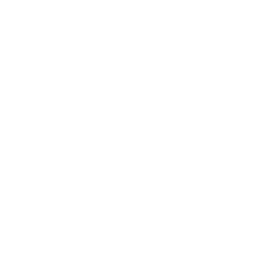
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnosi di Perturbazione del Reattore Chimico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identificare le variabili che determinano il superamento del limite T2 del reattore durante l'evento di perturbazione &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Un reattore a serbatoio agitato continuo (CSTR) e entrato in una perturbazione termica quando la sua alimentazione di refrigerante si e degradata. In condizioni operative normali, il flusso di refrigerante, la temperatura del reattore e la temperatura della camicia si muovono insieme lungo un unico asse di carico di processo. Costruiamo un modello MVP a tre componenti su 100 osservazioni di funzionamento normale, quindi valutiamo 100 osservazioni di perturbazione rispetto ad esso con `PROC MVPDIAGNOSE`. Decomporre la statistica *T*-quadrato di Hotelling in contributi per variabile isola il terzetto termicamente accoppiato — `jacket_temp`, `coolant_flow` e `reactor_temp` — come le variabili che determinano il superamento del limite, indirizzando le operazioni direttamente al sottosistema di refrigerazione.


## Fonti dei Dati

| Dataset | Ruolo | Osservazioni |
|---|---|---|
| `reactor_normal` | Dati di addestramento in funzionamento normale per il modello MVP | 100 |
| `reactor_upset` | Osservazioni dell'evento di perturbazione valutate rispetto al modello | 100 |

Le cinque variabili misurate sono `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) e `pressure` (bar).
Entrambi i dataset sono simulati a partire da un comune carico di
processo latente, cosi' che i dati normali portino la stessa struttura
di correlazione che un CSTR reale presenta; la perturbazione inietta
una perdita di alimentazione del refrigerante che rompe tale struttura.


## Passo 1 — Addestrare il modello MVP di funzionamento normale

Il funzionamento normale e governato da un carico di processo latente:
un carico piu alto riduce il flusso di refrigerante mentre innalza le
temperature del reattore e della camicia. `PROC MVPMODEL` estrae tre
componenti principali dalle 100 osservazioni normali e le conserva con
`OUTMODEL=` cosi' che il passo di diagnosi possa valutare nuovi dati
rispetto allo stesso riferimento.


In [1]:
DATI reactor_normal;
  CHIAMARE streaminit(7);
  FARE t = 1 FINO_A 100;
    LOAD = rand('normal', 0, 1);                 /* carico di processo latente */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    USCITA;
  FINE;
ESEGUIRE;

PROCEDURA mvpmodel DATI=reactor_normal outmodel=reactor_model;
  VARIABILE reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
ESEGUIRE;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Passo 2 — Valutare l'evento di perturbazione e decomporre *T*-quadrato

La perturbazione riduce il flusso di refrigerante di circa 12 L/min
mentre le temperature del reattore e della camicia aumentano —
l'accoppiamento normale tra refrigerante e temperatura si rompe.
`PROC MVPDIAGNOSE` valuta ogni osservazione della perturbazione rispetto
al modello di riferimento, scrivendo i punteggi standardizzati e i
residui in `OUT=` e i contributi di *T*-quadrato per variabile in
`OUTCONTRIB=`. Tutte le osservazioni cadono ben oltre il limite di
controllo, confermando un'escursione multivariata sostenuta piuttosto
che rumore isolato.


In [2]:
DATI reactor_upset;
  CHIAMARE streaminit(101);
  FARE t = 1 FINO_A 100;
    LOAD = rand('normal', 0, 1);
    /* La pompa del refrigerante si degrada: il flusso cala, le temperature si impennano */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    obs_time = t;
    USCITA;
  FINE;
ESEGUIRE;

PROCEDURA mvpdiagnose DATI=reactor_upset model=reactor_model
                 out=reactor_scores;
  VARIABILE reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
ESEGUIRE;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Passo 3 — Classificare i contributi medi

`OUTCONTRIB=` scrive una riga per ogni osservazione valutata, con una
colonna `<variable>_CONTRIB` per ciascuna variabile di processo.
Calcolare la media di queste colonne fornisce il contributo medio di
ciascuna variabile alla perturbazione; una trasposizione riorganizza il
riepilogo a riga singola in una tabella ordinata variabile/valore che
classifica i fattori del guasto.


In [3]:
PROCEDURA MEDIE DATI=reactor_contrib mean NOPRINT;
  VARIABILE reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  USCITA out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
ESEGUIRE;

PROCEDURA TRANSPOSE DATI=contrib_means out=contrib_long name=metric;
  VARIABILE mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
ESEGUIRE;

/* Assegna nomi di variabile leggibili e il valore di contributo medio */
DATI contrib_ranked;
  IMPOSTARE contrib_long;
  LUNGHEZZA variable $14;
  SE_COND      metric = 'mc_reactor_temp' ALLORA variable = 'reactor_temp';
  ALTRIMENTI SE_COND metric = 'mc_coolant_flow' ALLORA variable = 'coolant_flow';
  ALTRIMENTI SE_COND metric = 'mc_jacket_temp'  ALLORA variable = 'jacket_temp';
  ALTRIMENTI SE_COND metric = 'mc_feed_conc'    ALLORA variable = 'feed_conc';
  ALTRIMENTI SE_COND metric = 'mc_pressure'     ALLORA variable = 'pressure';
  mean_contrib = col1;
  MANTENERE variable mean_contrib;
ESEGUIRE;

PROCEDURA ORDINARE DATI=contrib_ranked;
  PER DISCENDENTE mean_contrib;
ESEGUIRE;

PROCEDURA STAMPARE DATI=contrib_ranked noobs ETICHETTA;
  VARIABILE variable mean_contrib;
  ETICHETTA variable="Variabile di Processo" mean_contrib="Contributo Medio a T-quadrato";
ESEGUIRE;



Variabile di Processo  Contributo Medio a T-quadrato
---------------------  -----------------------------
jacket_temp                            4177.66720283
coolant_flow                           2882.19501987
reactor_temp                           1602.04200377
pressure                                280.73140863
feed_conc                                61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/5ae5a95c-de31-4de0-976a-82e368d54a1f/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Passo 4 — Grafico di contributo

Il grafico di contributo rende immediata la diagnosi: il terzetto
termicamente accoppiato — `jacket_temp`, `coolant_flow` e
`reactor_temp` — eclissa `feed_conc` e `pressure`, che si registrano a
malapena. Le tre barre dominanti sono esattamente le variabili
collegate dal circuito di refrigerazione, quindi il guasto e
inequivocabilmente termico, non un problema di alimentazione o di
pressione.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


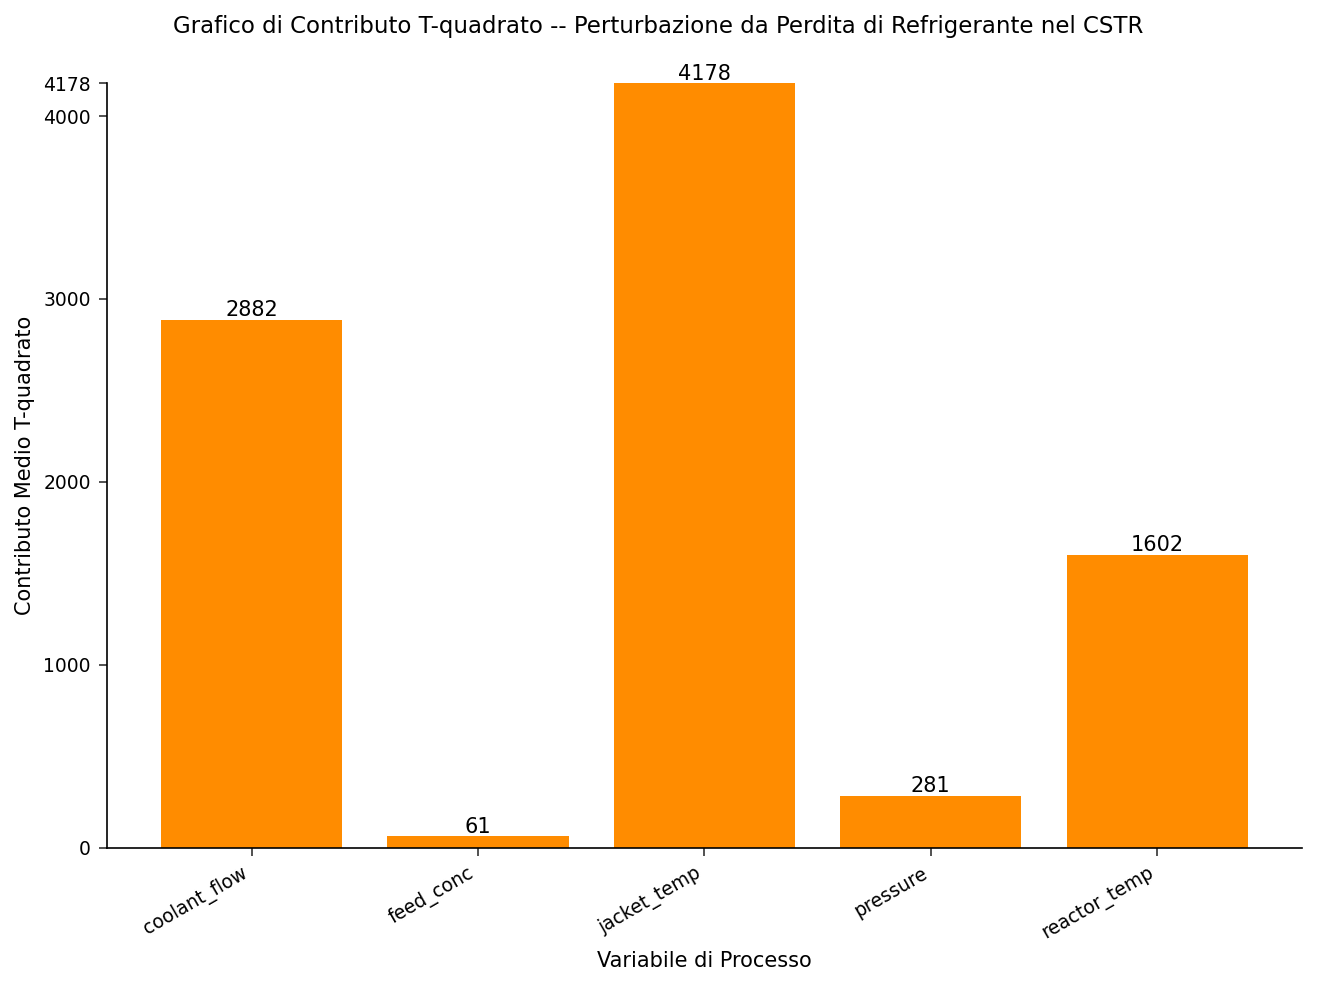

In [4]:
PROCEDURA SGPLOT DATI=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ETICHETTA='Variabile di Processo';
  YAXIS ETICHETTA='Contributo Medio T-quadrato';
  TITOLO 'Grafico di Contributo T-quadrato -- Perturbazione da Perdita di Refrigerante nel CSTR';
ESEGUIRE;


## Passo 5 — Cronologia di controllo di *T*-quadrato

Rappresentare il *T*-quadrato di ogni osservazione rispetto al limite
di controllo del modello mostra che l'escursione e continua: tutte le
osservazioni della perturbazione si collocano ordini di grandezza sopra
la linea di riferimento del limite. Non c'e recupero all'interno della
finestra, il che e coerente con un guasto hardware che persiste finche
il sottosistema di refrigerazione non viene riparato.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


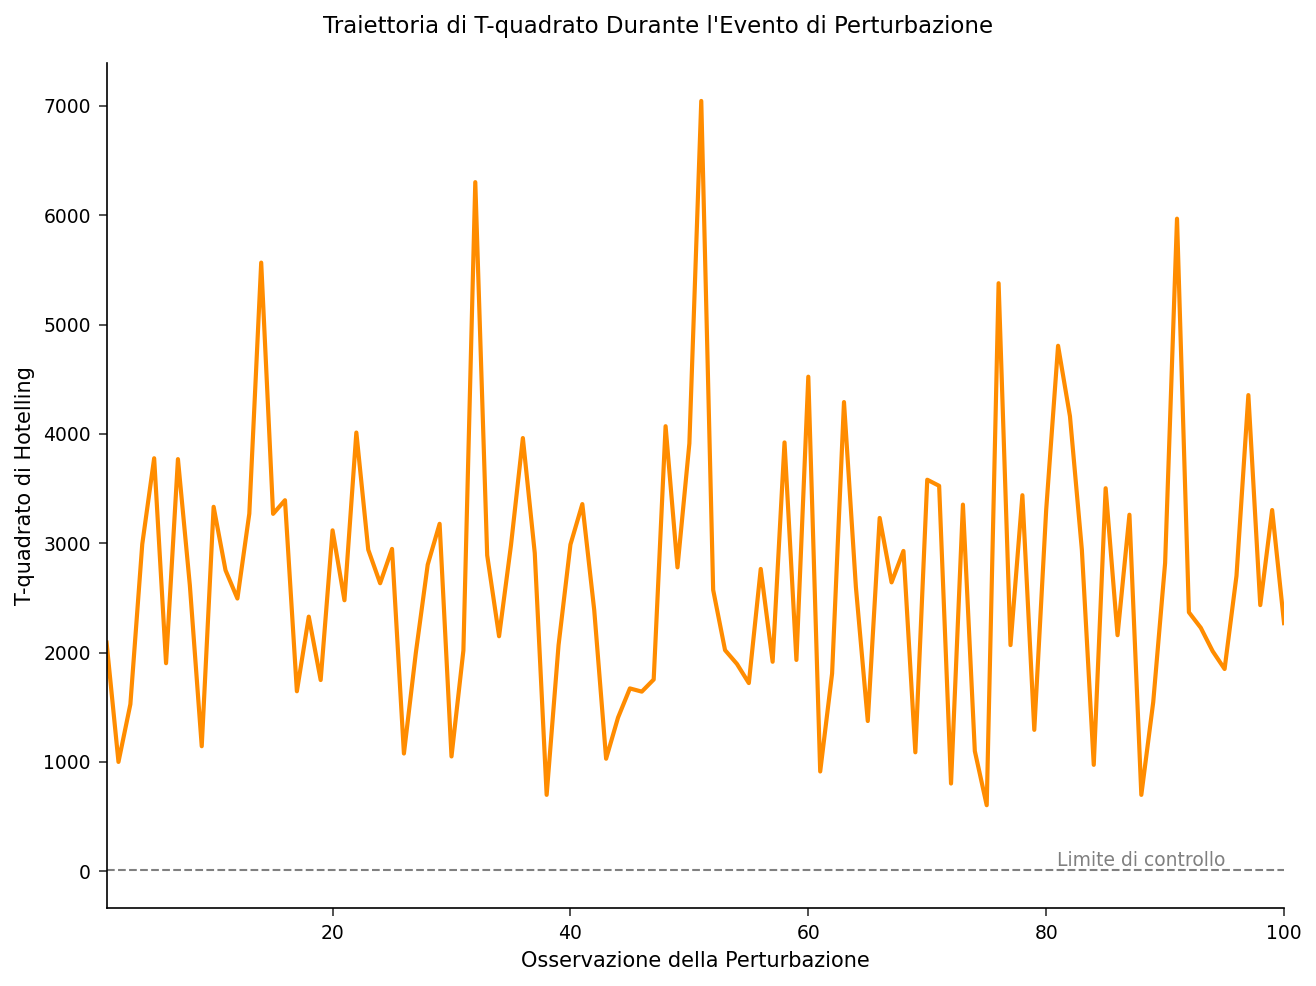

In [5]:
PROCEDURA SGPLOT DATI=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ETICHETTA='Limite di controllo'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ETICHETTA='Osservazione della Perturbazione';
  YAXIS ETICHETTA='T-quadrato di Hotelling';
  TITOLO "Traiettoria di T-quadrato Durante l'Evento di Perturbazione";
ESEGUIRE;


## Risultati e Azione Correttiva

- **Principali fattori**: `jacket_temp`, `coolant_flow` e
  `reactor_temp` spiegano insieme praticamente tutto il segnale di
  *T*-quadrato; i loro contributi medi sono da uno a due ordini di
  grandezza superiori a quelli di `feed_conc` e `pressure`.
- **Causa radice**: una perdita di alimentazione del refrigerante.
  `coolant_flow` e l'unica variabile *manipolata* tra le tre — gli
  aumenti di temperatura sono conseguenze a valle della perdita di
  raffreddamento, quindi il guasto azionabile e il sottosistema di
  refrigerazione.
- **Stato di controllo**: tutte le 100 osservazioni della perturbazione
  superano il limite di *T*-quadrato, indicando un'escursione sostenuta
  piuttosto che qualcosa di transitorio.
- **Azione correttiva**: ispezionare e ricostruire la pompa del
  refrigerante; aggiungere un trasmettitore di flusso di refrigerante
  ridondante cosi' che una futura perdita di alimentazione venga
  rilevata tramite allarme univariato prima che si propaghi al circuito
  di temperatura.


## Esportare i contributi classificati

La tabella dei contributi classificati viene scritta in CSV per il
rapporto post-evento e le dashboard successive.


In [6]:
PROCEDURA EXPORT DATI=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>